# Smart Blur Selector (Exercise P2)
Simplified version (no small image).

In [2]:
import cv2
import numpy as np
import time
import matplotlib.pyplot as plt

## Put your input image inside 'images/input.jpg'

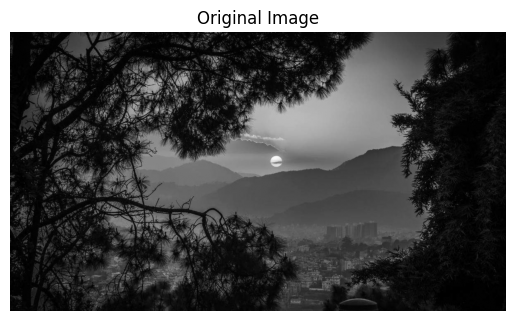

In [ ]:
# Load image
img = cv2.imread('input_images/bai2/image.jpg', cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Image not found! Please put 'input.jpg' inside 'input_images/bai2/' folder")

plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

In [4]:
def gaussian_kernel(k):
    g = cv2.getGaussianKernel(k, -1)
    return g @ g.T

In [5]:
def fft_blur(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape

    pad = np.zeros((h, w))
    pad[:kh, :kw] = kernel

    F = np.fft.fft2(image)
    H = np.fft.fft2(pad)

    G = F * H
    result = np.fft.ifft2(G)

    return np.real(result)

In [6]:
def benchmark(image, kernel):
    crop = image[:100, :100]

    start = time.time()
    _ = cv2.filter2D(crop, -1, kernel)
    t_spatial = time.time() - start

    start = time.time()
    _ = fft_blur(crop, kernel)
    t_fft = time.time() - start

    return t_spatial, t_fft

In [7]:
def smart_blur(image, k, save_path=None):
    kernel = gaussian_kernel(k)

    t_spatial, t_fft = benchmark(image, kernel)

    if t_spatial < t_fft:
        method = 'spatial'
        result = cv2.filter2D(image, -1, kernel)
    else:
        method = 'fft'
        result = fft_blur(image, kernel)

    result = np.clip(result, 0, 255).astype(np.uint8)

    if save_path:
        cv2.imwrite(save_path, result)

    print(f"Kernel size: {k}")
    print(f"Spatial time: {t_spatial:.6f}s")
    print(f"FFT time: {t_fft:.6f}s")
    print(f"Chosen method: {method}\n")

    return result

Kernel size: 5
Spatial time: 0.000000s
FFT time: 0.006001s
Chosen method: spatial

Kernel size: 15
Spatial time: 0.000899s
FFT time: 0.000000s
Chosen method: fft

Kernel size: 31
Spatial time: 0.000985s
FFT time: 0.000000s
Chosen method: fft

Kernel size: 51
Spatial time: 0.000997s
FFT time: 0.000000s
Chosen method: fft



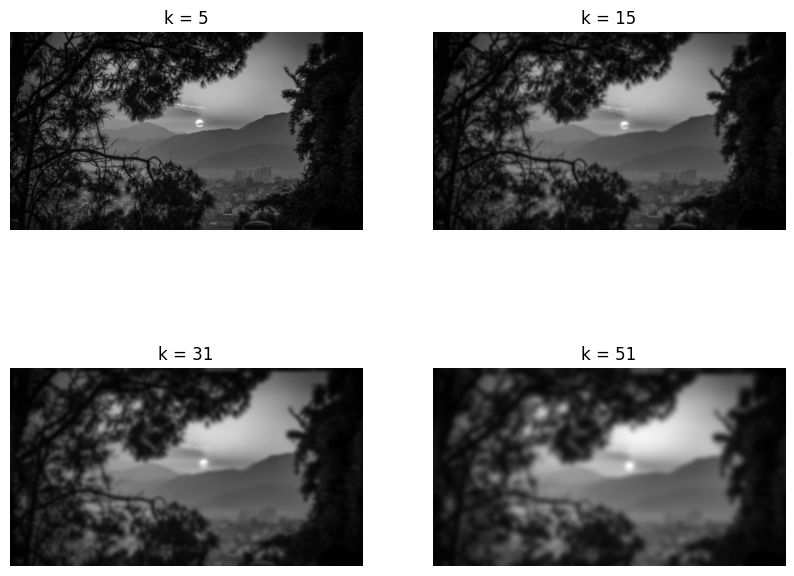

Done. Results saved in 'output_images/bai1' folder.


In [ ]:
# Run experiments
kernel_sizes = [5, 15, 31, 51]
output_dir = 'output_images/bai2'

plt.figure(figsize=(10, 8))

for i, k in enumerate(kernel_sizes):
    result = smart_blur(img, k, save_path=f'{output_dir}/result_k{k}.jpg')

    plt.subplot(2, 2, i+1)
    plt.imshow(result, cmap='gray')
    plt.title(f'k = {k}')
    plt.axis('off')

plt.show()

print(f"Done. Results saved in '{output_dir}' folder.")